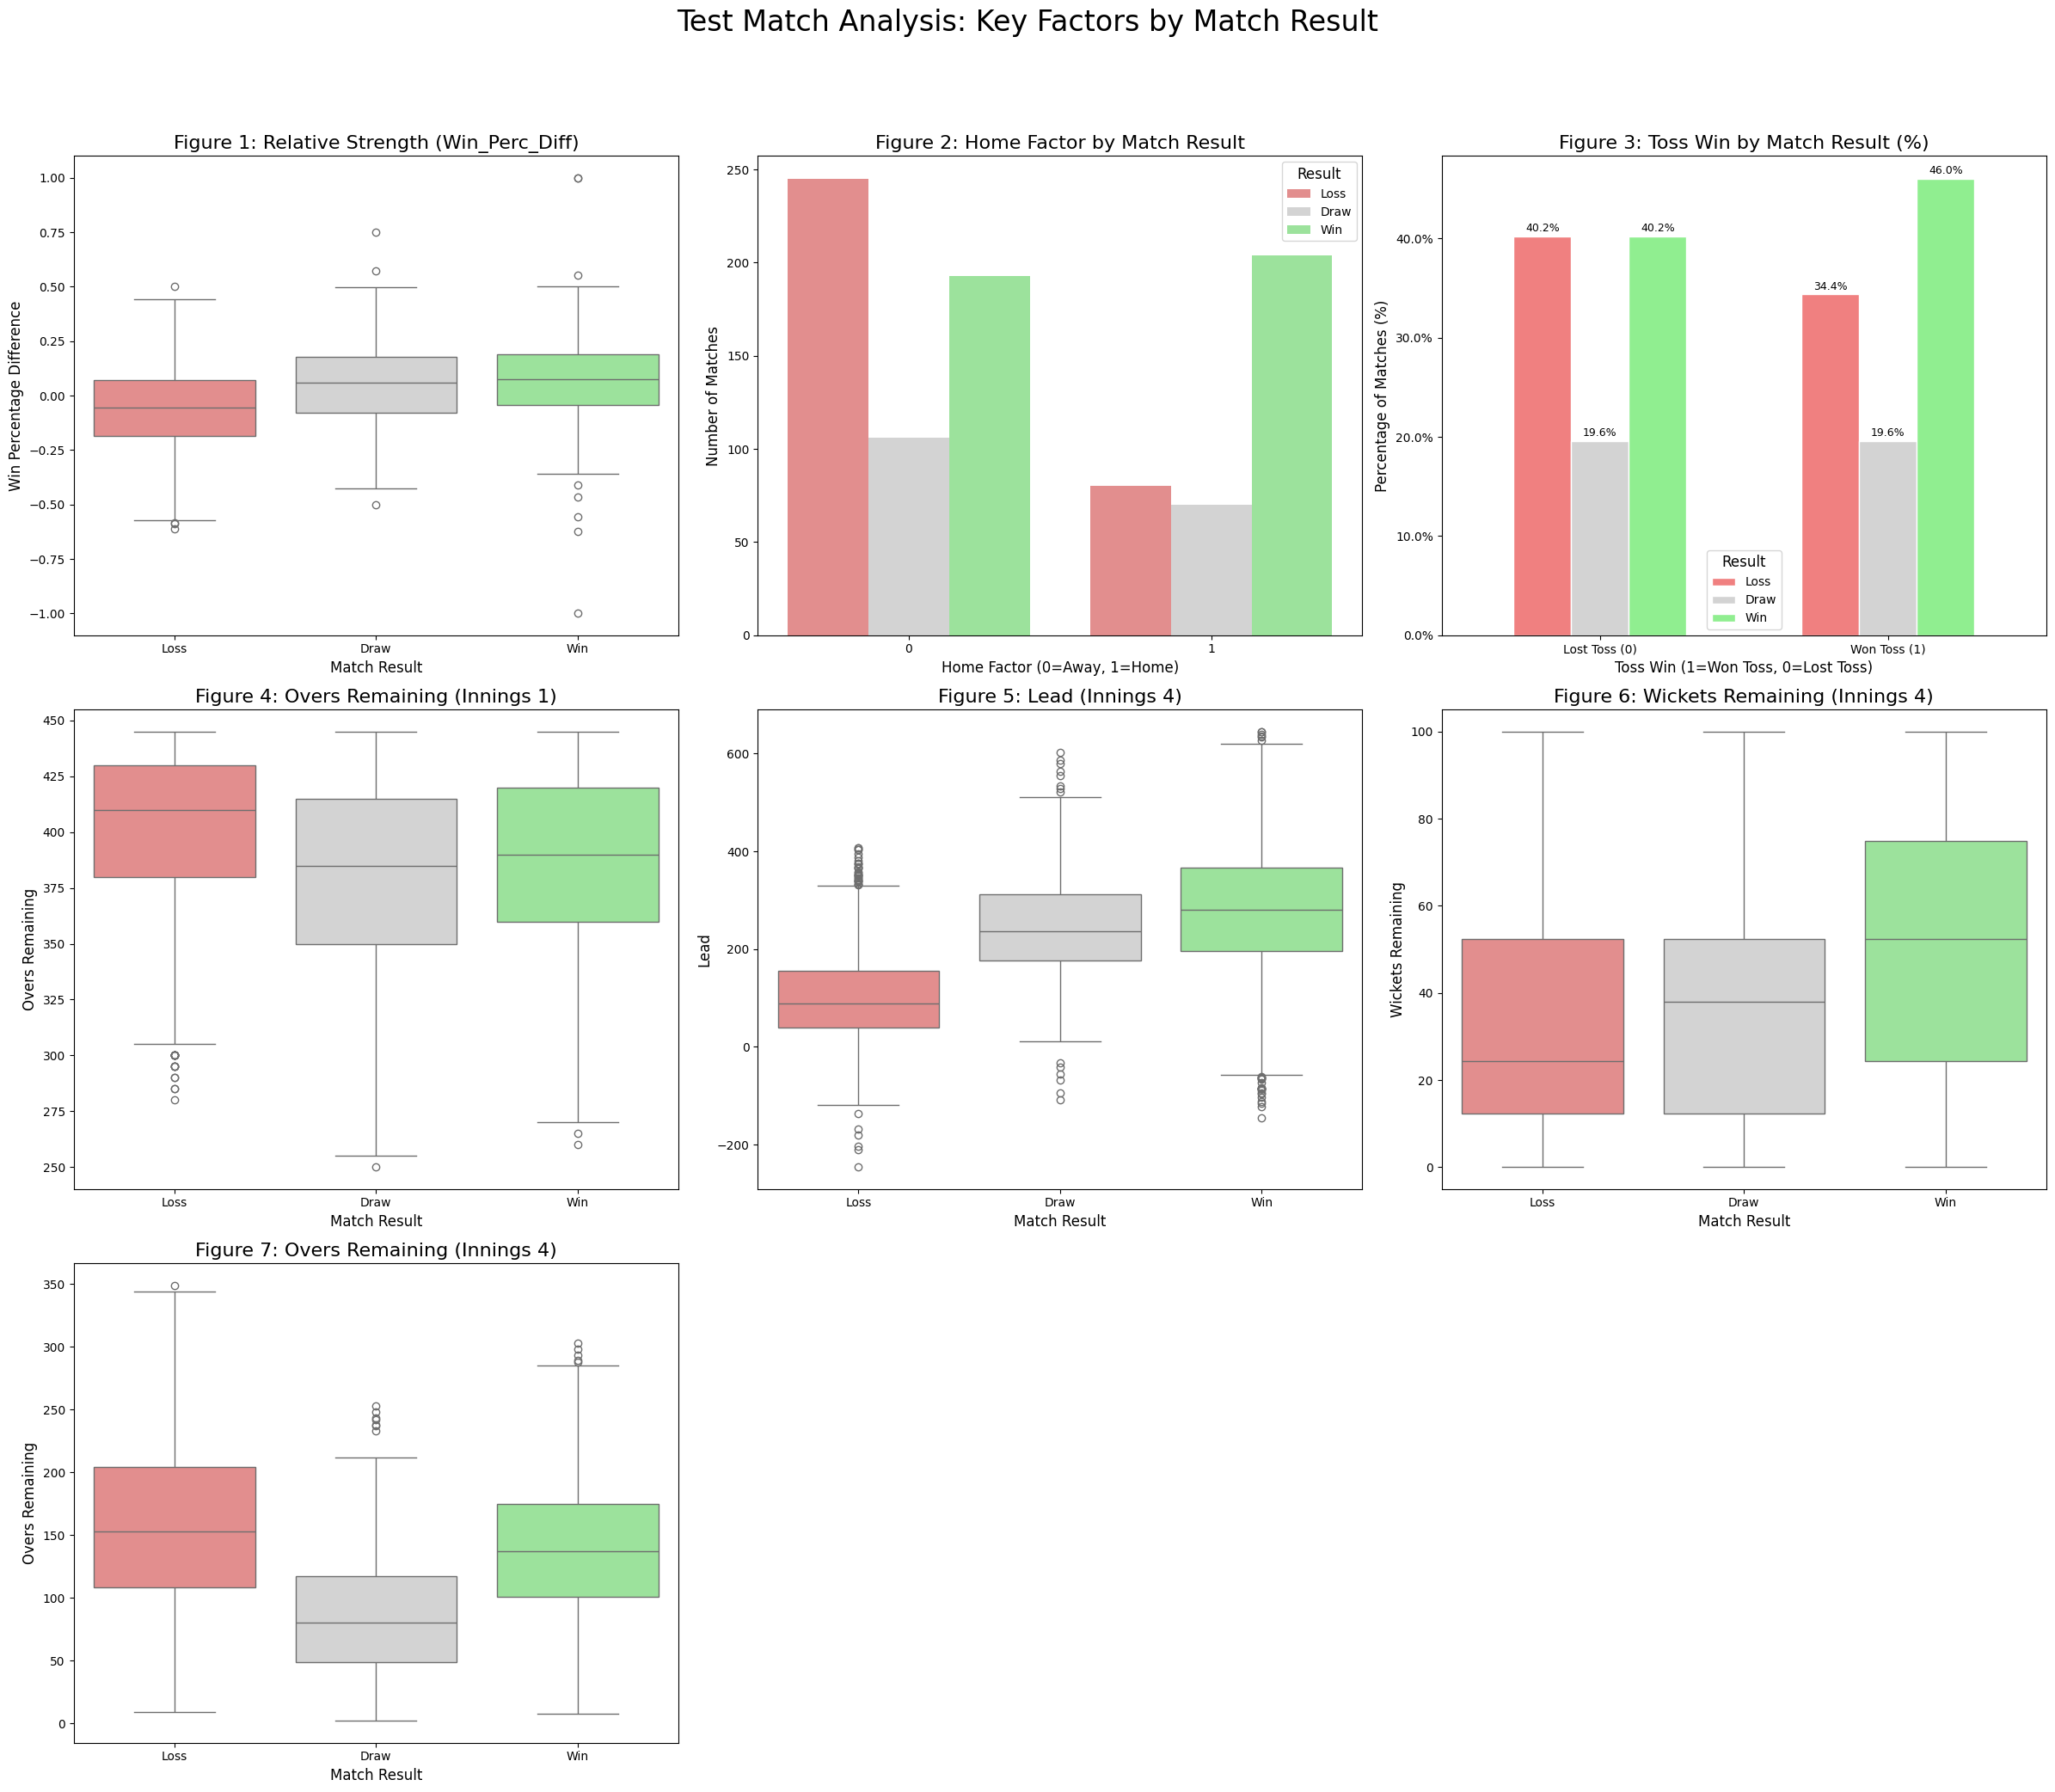

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Load the dataset
df = pd.read_csv('cricket_features_with_defense_final.csv')

# Map the Result column
result_mapping = {-1: 'Loss', 0: 'Draw', 1: 'Win'}
df['Result_Mapped'] = df['Result'].map(result_mapping)

# ✅ Deduplicated dataframe — one row per match
df_match_level = df.drop_duplicates(subset='Match_ID').copy()
df_match_level['Result_Mapped'] = df_match_level['Result'].map(result_mapping)
df_match_level['Home_Factor'] = df_match_level['Home_Factor'].astype(str)
df_match_level['Toss_Win'] = df_match_level['Toss_Win'].astype(str)

fig, axes = plt.subplots(3, 3, figsize=(24, 21))
fig.suptitle('Test Match Analysis: Key Factors by Match Result', fontsize=24, y=1.02)

palette_results = {'Loss': 'lightcoral', 'Draw': 'lightgray', 'Win': 'lightgreen'}
order = ['Loss', 'Draw', 'Win']

# --- Fig 1: Relative Strength ---
# ✅ deduplicated — match-level feature
sns.boxplot(x='Result_Mapped', y='Win_Perc_Diff', data=df_match_level,
            palette=palette_results, ax=axes[0, 0], order=order,
            hue='Result_Mapped', legend=False)
axes[0, 0].set_title('Figure 1: Relative Strength (Win_Perc_Diff)', fontsize=16)
axes[0, 0].set_xlabel('Match Result', fontsize=12)
axes[0, 0].set_ylabel('Win Percentage Difference', fontsize=12)

# --- Fig 2: Home Factor ---
# ✅ deduplicated — match-level feature
sns.countplot(x='Home_Factor', hue='Result_Mapped', data=df_match_level,
              palette=palette_results, ax=axes[0, 1], hue_order=order)
axes[0, 1].set_title('Figure 2: Home Factor by Match Result', fontsize=16)
axes[0, 1].set_xlabel('Home Factor (0=Away, 1=Home)', fontsize=12)
axes[0, 1].set_ylabel('Number of Matches', fontsize=12)
axes[0, 1].legend(title='Result', fontsize=10, title_fontsize=12)

# --- Fig 3: Toss Win — ✅ USE PROPORTIONS to fix JSON ordering bias ---
# Raw counts are misleading because toss_win=1 is inflated due to
# JSON team ordering bias (teams[0] wins toss 60%+ of the time)
# Proportions show true win/loss/draw rate within each toss outcome group
toss_props = (pd.crosstab(df_match_level['Toss_Win'],
                           df_match_level['Result_Mapped'],
                           normalize='index') * 100)[order]

toss_props.plot(kind='bar', ax=axes[0, 2],
                color=[palette_results[c] for c in order],
                edgecolor='white', width=0.6)
axes[0, 2].set_title('Figure 3: Toss Win by Match Result (%)', fontsize=16)
axes[0, 2].set_xlabel('Toss Win (1=Won Toss, 0=Lost Toss)', fontsize=12)
axes[0, 2].set_ylabel('Percentage of Matches (%)', fontsize=12)
axes[0, 2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0, 2].set_xticklabels(['Lost Toss (0)', 'Won Toss (1)'], rotation=0)
axes[0, 2].legend(title='Result', fontsize=10, title_fontsize=12)
for container in axes[0, 2].containers:
    axes[0, 2].bar_label(container, fmt='%.1f%%', fontsize=9, padding=2)

# --- Fig 4: Overs Remaining (Innings 1) ---
df_innings1 = df[df['Innings_Num'] == 1].copy()
df_innings1['Result_Mapped'] = df_innings1['Result'].map(result_mapping)
sns.boxplot(x='Result_Mapped', y='Overs_Remaining', data=df_innings1,
            palette=palette_results, ax=axes[1, 0], order=order,
            hue='Result_Mapped', legend=False)
axes[1, 0].set_title('Figure 4: Overs Remaining (Innings 1)', fontsize=16)
axes[1, 0].set_xlabel('Match Result', fontsize=12)
axes[1, 0].set_ylabel('Overs Remaining', fontsize=12)

# --- Fig 5: Lead (Innings 4) ---
df_innings4 = df[df['Innings_Num'] == 4].copy()
df_innings4['Result_Mapped'] = df_innings4['Result'].map(result_mapping)
sns.boxplot(x='Result_Mapped', y='Lead', data=df_innings4,
            palette=palette_results, ax=axes[1, 1], order=order,
            hue='Result_Mapped', legend=False)
axes[1, 1].set_title('Figure 5: Lead (Innings 4)', fontsize=16)
axes[1, 1].set_xlabel('Match Result', fontsize=12)
axes[1, 1].set_ylabel('Lead', fontsize=12)

# --- Fig 6: Wickets Remaining (Innings 4) ---
sns.boxplot(x='Result_Mapped', y='Opp_Wicket_Resources', data=df_innings4,
            palette=palette_results, ax=axes[1, 2], order=order,
            hue='Result_Mapped', legend=False)
axes[1, 2].set_title('Figure 6: Wickets Remaining (Innings 4)', fontsize=16)
axes[1, 2].set_xlabel('Match Result', fontsize=12)
axes[1, 2].set_ylabel('Wickets Remaining', fontsize=12)

# --- Fig 7: Overs Remaining (Innings 4) ---
sns.boxplot(x='Result_Mapped', y='Overs_Remaining', data=df_innings4,
            palette=palette_results, ax=axes[2, 0], order=order,
            hue='Result_Mapped', legend=False)
axes[2, 0].set_title('Figure 7: Overs Remaining (Innings 4)', fontsize=16)
axes[2, 0].set_xlabel('Match Result', fontsize=12)
axes[2, 0].set_ylabel('Overs Remaining', fontsize=12)

# Hide unused subplots
for i in range(1, 3):
    fig.delaxes(axes[2, i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig('test_match_analysis_complete.png', dpi=150, bbox_inches='tight')
plt.show()

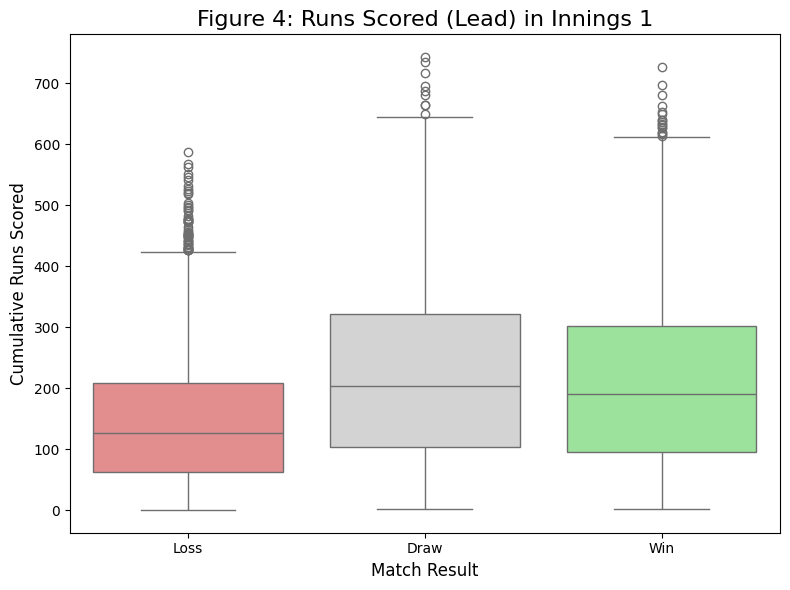

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('cricket_features_with_defense_final.csv')

# Map the Result column
result_mapping = {-1: 'Loss', 0: 'Draw', 1: 'Win'}
palette_results = {'Loss': 'lightcoral', 'Draw': 'lightgray', 'Win': 'lightgreen'}
order = ['Loss', 'Draw', 'Win']

# Filter Innings 1
df_inn1 = df[df['Innings_Num'] == 1].copy()
df_inn1['Result_Mapped'] = df_inn1['Result'].map(result_mapping)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# ✅ FIXED: Use Lead instead of Ref_Wicket_Resources
# Lead in Innings 1 = cumulative runs scored by Reference Team
# Higher score in Inn1 → more likely to Win or Draw
# This mirrors the paper's "Lead of Team A" concept
sns.boxplot(x='Result_Mapped', y='Lead', data=df_inn1,
            palette=palette_results, ax=ax, order=order,
            hue='Result_Mapped', legend=False)

ax.set_title('Figure 4: Runs Scored (Lead) in Innings 1', fontsize=16)
ax.set_xlabel('Match Result', fontsize=12)
ax.set_ylabel('Cumulative Runs Scored', fontsize=12)

plt.tight_layout()
plt.savefig('fig4_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

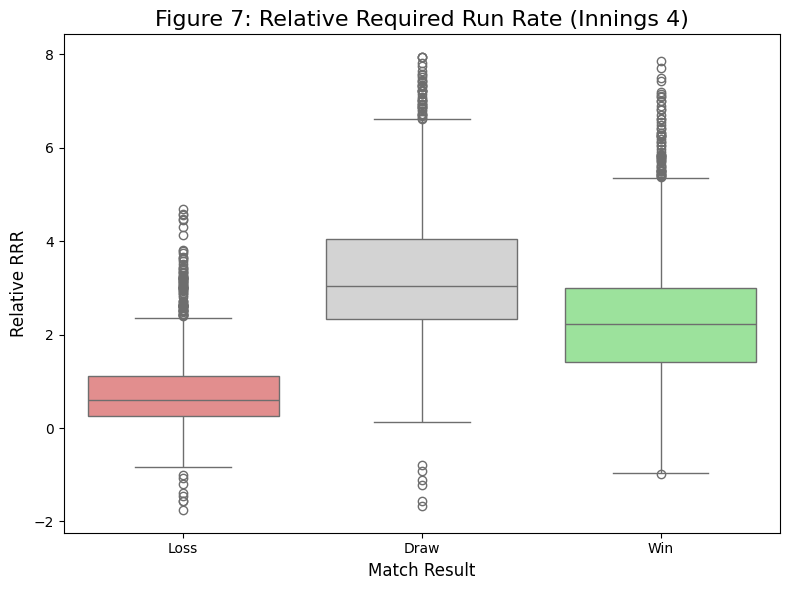

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cricket_features_with_defense_final.csv')

result_mapping = {-1: 'Loss', 0: 'Draw', 1: 'Win'}
palette_results = {'Loss': 'lightcoral', 'Draw': 'lightgray', 'Win': 'lightgreen'}
order = ['Loss', 'Draw', 'Win']

# Filter Innings 4
df_inn4 = df[df['Innings_Num'] == 4].copy()
df_inn4['Result_Mapped'] = df_inn4['Result'].map(result_mapping)

# Remove extreme outliers in Relative_RRR for cleaner plot (Draw has max=94.5)
# Cap at 99th percentile
cap = df_inn4['Relative_RRR'].quantile(0.99)
df_inn4_capped = df_inn4[df_inn4['Relative_RRR'] <= cap].copy()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# ✅ Relative_RRR = Required Run Rate relative to scoring rate
# High value = target is too hard to chase (Draw)
# Low value  = target is easy but team still got bowled out (Loss)
# Mid value  = Reference team set a tough but chaseable target, defended it (Win)
sns.boxplot(x='Result_Mapped', y='Relative_RRR', data=df_inn4_capped,
            palette=palette_results, ax=ax, order=order,
            hue='Result_Mapped', legend=False)

ax.set_title('Figure 7: Relative Required Run Rate (Innings 4)', fontsize=16)
ax.set_xlabel('Match Result', fontsize=12)
ax.set_ylabel('Relative RRR', fontsize=12)

plt.tight_layout()
plt.savefig('fig7_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

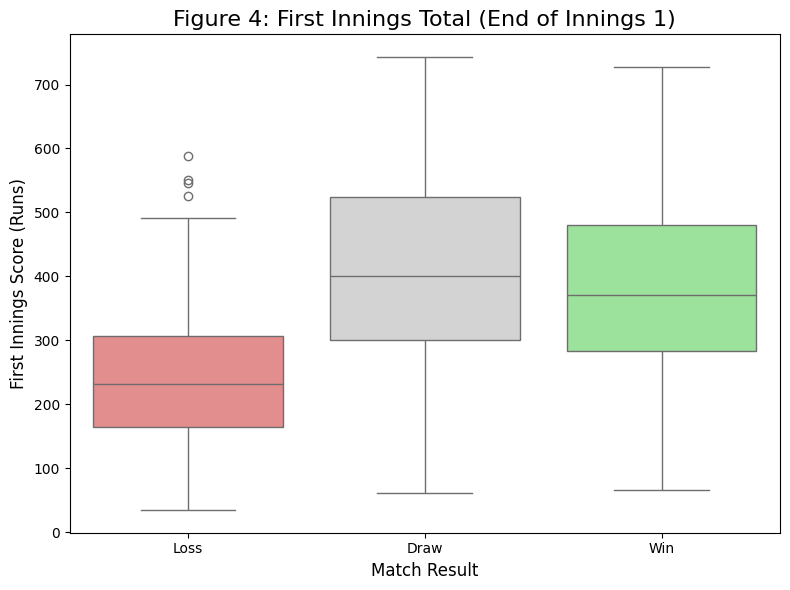

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cricket_features_with_defense_final.csv')

result_mapping = {-1: 'Loss', 0: 'Draw', 1: 'Win'}
palette_results = {'Loss': 'lightcoral', 'Draw': 'lightgray', 'Win': 'lightgreen'}
order = ['Loss', 'Draw', 'Win']

df_inn1 = df[df['Innings_Num'] == 1].copy()
df_inn1['Result_Mapped'] = df_inn1['Result'].map(result_mapping)

# ✅ Take LAST row per match = final score at end of Innings 1
# This shows the actual first innings total, not cumulative mid-innings rows
# Loss: scored least (~232) → behind from start
# Win:  scored well (~371) → set up strong position
# Draw: scored most (~400) → batted very long, match ran out of time
df_inn1_end = df_inn1.groupby('Match_ID').last().reset_index()
df_inn1_end['Result_Mapped'] = df_inn1_end['Result'].map(result_mapping)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.boxplot(x='Result_Mapped', y='Lead', data=df_inn1_end,
            palette=palette_results, ax=ax, order=order,
            hue='Result_Mapped', legend=False)

ax.set_title('Figure 4: First Innings Total (End of Innings 1)', fontsize=16)
ax.set_xlabel('Match Result', fontsize=12)
ax.set_ylabel('First Innings Score (Runs)', fontsize=12)

plt.tight_layout()
plt.savefig('fig4_final.png', dpi=150, bbox_inches='tight')
plt.show()